In [1]:
import experiment
import pandas as pd
import yaml
import numpy as np

/home/gruengroup/christian/Projects/notebook_repository/notebooks/2026-05-13T07-33-19Z/.venv/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/gruengroup/christian/Projects/notebook_repository/notebooks/2026-05-13T07-33-19Z/.venv/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/gruengroup/christian/Projects/notebook_repository/notebooks/2026-05-13T07-33-19Z/.venv/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [ ]:
df = pd.read_csv(
    "/home/gruengroup/christian/Projects/notebook_repository/notebooks/2026-05-13T07-33-19Z/old_output.csv"
)

In [2]:
df = pd.read_csv(
    "/home/gruengroup/christian/Projects/notebook_repository/notebooks/2026-05-13T07-33-19Z/output.csv"
)

In [5]:
df.groupby(
    [
        "dataset_name",
        "database_name",
        "cluster_name",
        "preprocessing_name",
        "scoring_function_name",
        "correlation_name",
    ]
)[["shuffle_probability", "score"]].corr().iloc[0::2, -1].reset_index()

,dataset_name,database_name,cluster_name,preprocessing_name,scoring_function_name,correlation_name,level_6,score
0,andy_reference,KEGG_2026,"('B_cells',)",identity,hypergeometric_max_enrichment_scoring,cosine_similarity,shuffle_probability,-0.836576
1,andy_reference,KEGG_2026,"('B_cells',)",identity,hypergeometric_max_enrichment_scoring,pearson,shuffle_probability,-0.954055
2,andy_reference,KEGG_2026,"('B_cells',)",identity,hypergeometric_max_enrichment_scoring,spearman,shuffle_probability,-0.860862
3,andy_reference,KEGG_2026,"('B_cells',)",identity,max_cosine_alignment_scoring,cosine_similarity,shuffle_probability,0.382300
4,andy_reference,KEGG_2026,"('B_cells',)",identity,max_cosine_alignment_scoring,pearson,shuffle_probability,-0.968272
...,...,...,...,...,...,...,...,...
499,andy_reference,KEGG_2026,"('vEC_Arterial',)",log1p,max_cosine_alignment_scoring,pearson,shuffle_probability,-0.978675
500,andy_reference,KEGG_2026,"('vEC_Arterial',)",log1p,max_cosine_alignment_scoring,spearman,shuffle_probability,-0.996370
501,andy_reference,KEGG_2026,"('vEC_Arterial',)",log1p,mutual_information_pathway_scoring,cosine_similarity,shuffle_probability,0.469643
502,andy_reference,KEGG_2026,"('vEC_Arterial',)",log1p,mutual_information_pathway_scoring,pearson,shuffle_probability,0.791801


In [ ]:
df["correlation_name"] = df["correlation_name"].fillna("None")

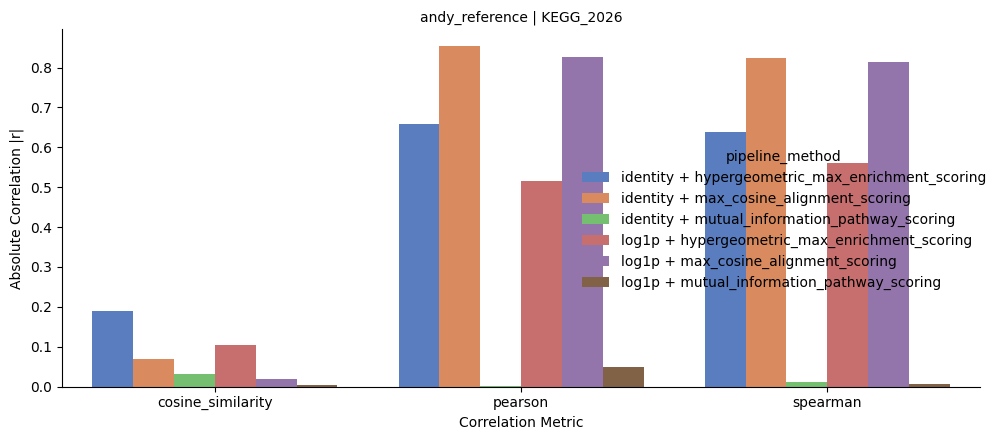

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group by everything except cluster_name to compute the baseline correlation
group_cols = [
    "dataset_name",
    "database_name",
    "preprocessing_name",
    "scoring_function_name",
    "correlation_name",
]
correlations = (
    df.groupby(group_cols)[["shuffle_probability", "score"]]
    .corr()
    .iloc[0::2, -1]
    .reset_index()
)
correlations["abs_score"] = correlations["score"].abs()

# 2. Combine preprocessing and scoring into a single hue category for cleaner plotting
correlations["pipeline_method"] = (
    correlations["preprocessing_name"] + " + " + correlations["scoring_function_name"]
)

# 3. Create the multi-faceted boxplot using catplot
g = sns.catplot(
    data=correlations,
    x="correlation_name",  # Distinct metrics grouped side-by-side on X axis
    y="abs_score",  # The metric being evaluated
    hue="pipeline_method",  # Color-coded strategy comparisons
    col="database_name",  # Subplots broken down horizontally
    row="dataset_name",  # Subplots broken down vertically
    kind="bar",  # Boxplot representation
    height=4.5,  # Height of each individual subplot facet
    aspect=1.3,  # Width-to-height ratio of facets
    palette="muted",
    legend=True,
)

# 4. Polish up the labels and layout
g.set_axis_labels("Correlation Metric", "Absolute Correlation |r|")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.tight_layout()
plt.show()

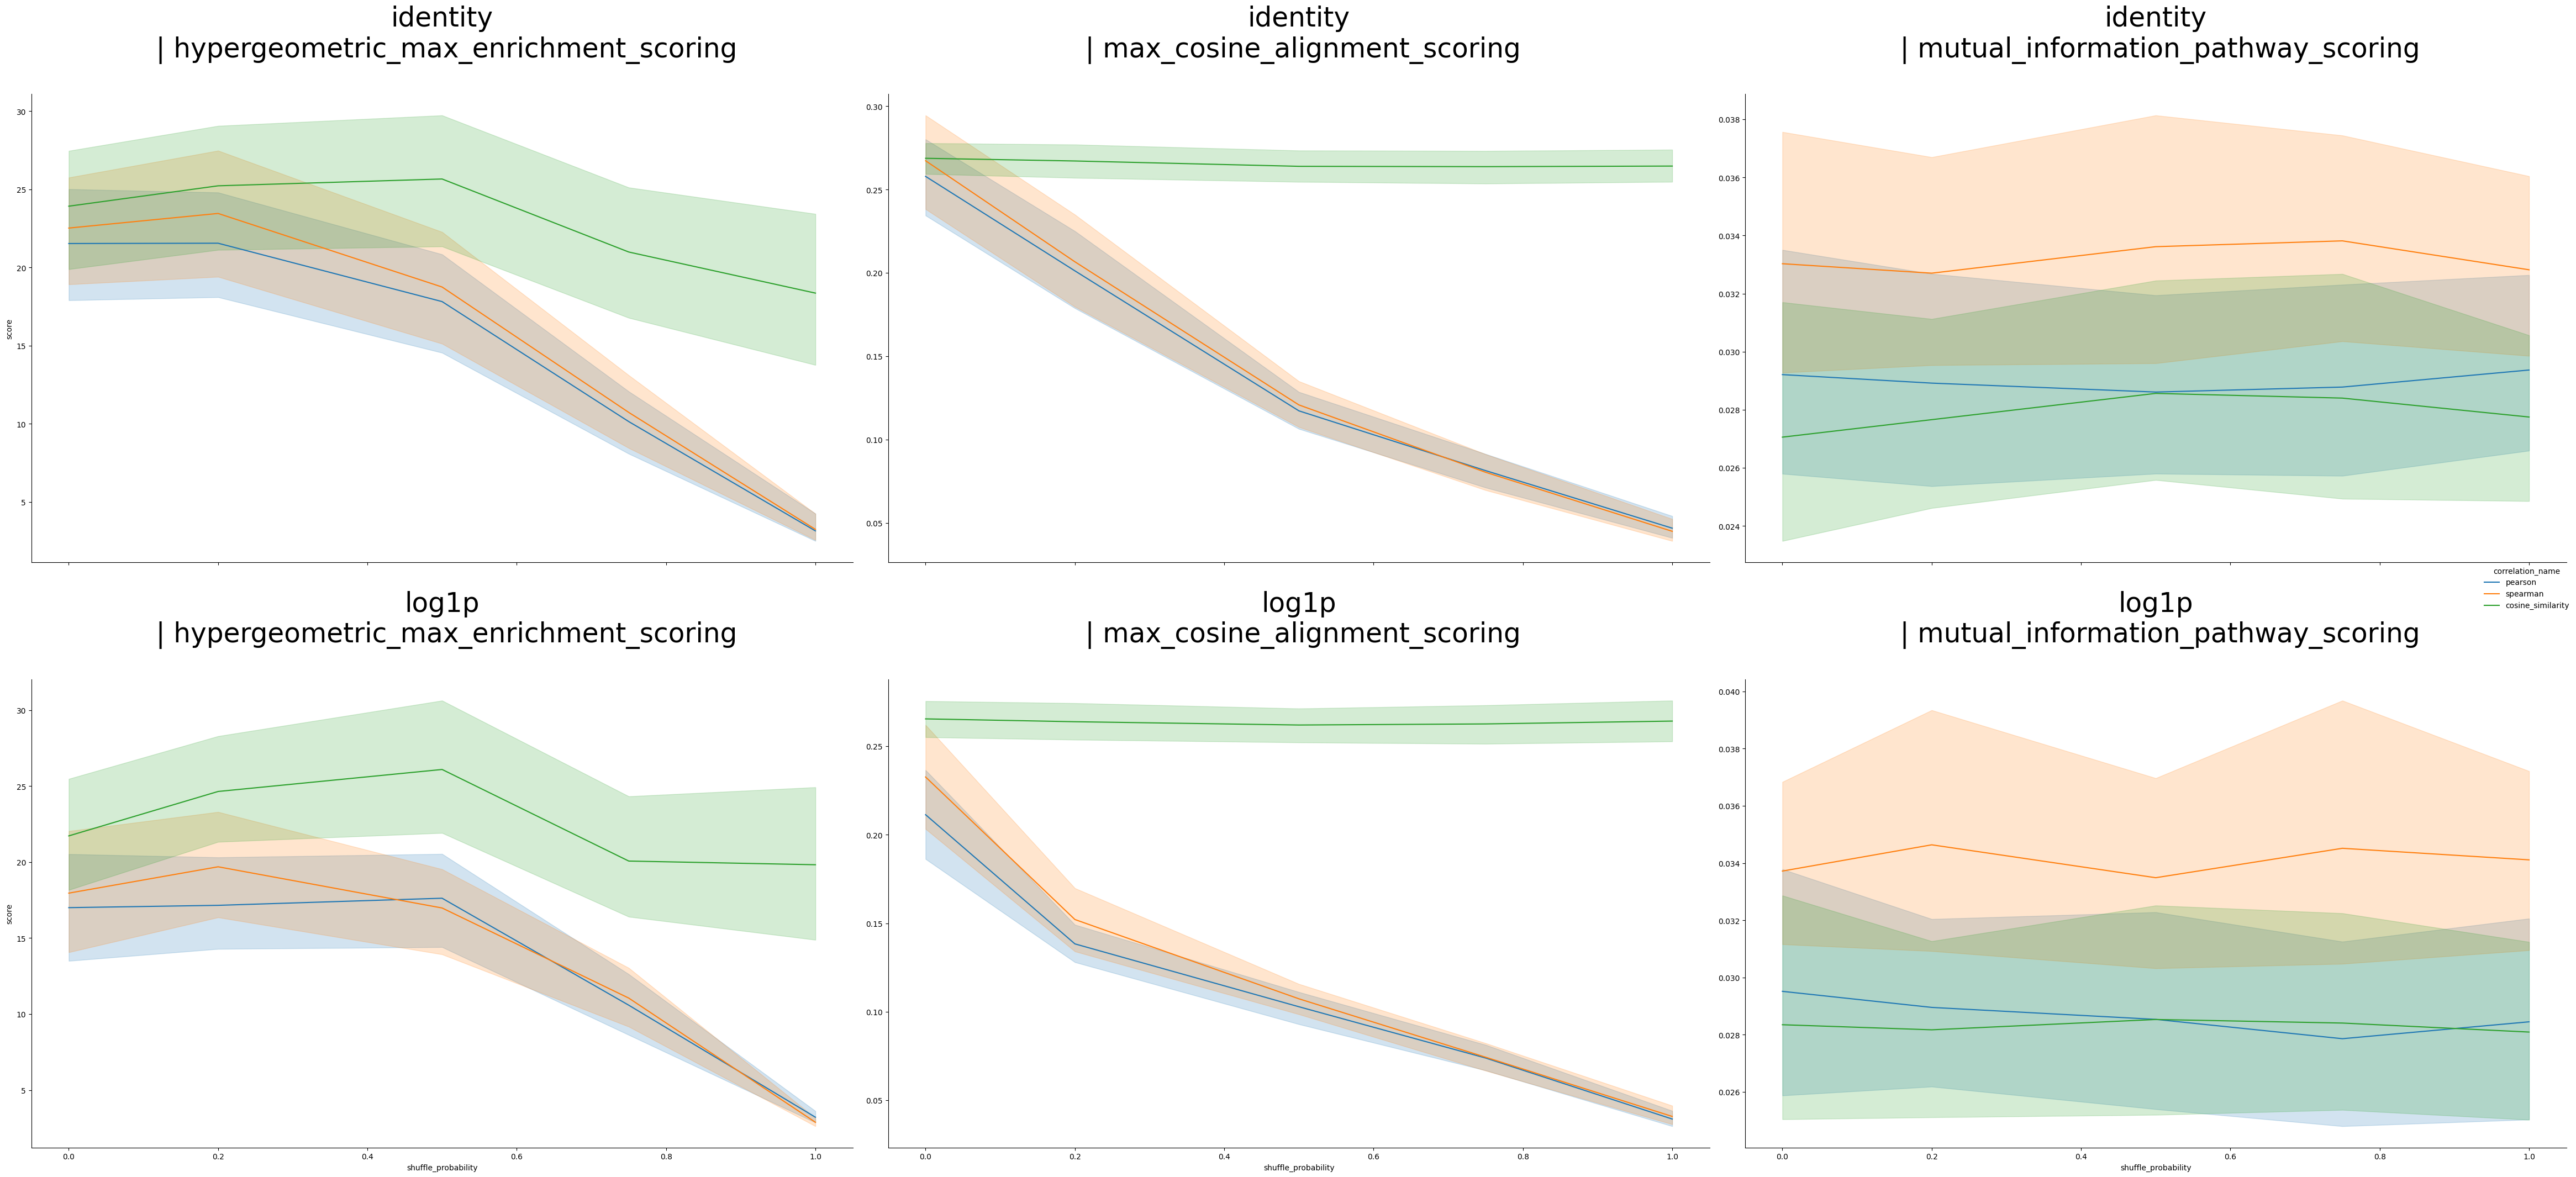

In [7]:
g = sns.relplot(
    data=df,
    x="shuffle_probability",
    y="score",
    hue="correlation_name",
    row="preprocessing_name",
    col="scoring_function_name",
    kind="line",
    facet_kws={"sharey": False},
    aspect=1.5,
    height=10,
    # sharey=False,
)
g.figure.tight_layout()
g.set_titles(
    row_template="{row_name}\n",
    col_template="{col_name}\n",
    size=35,
)
g.figure.subplots_adjust(hspace=0.25)

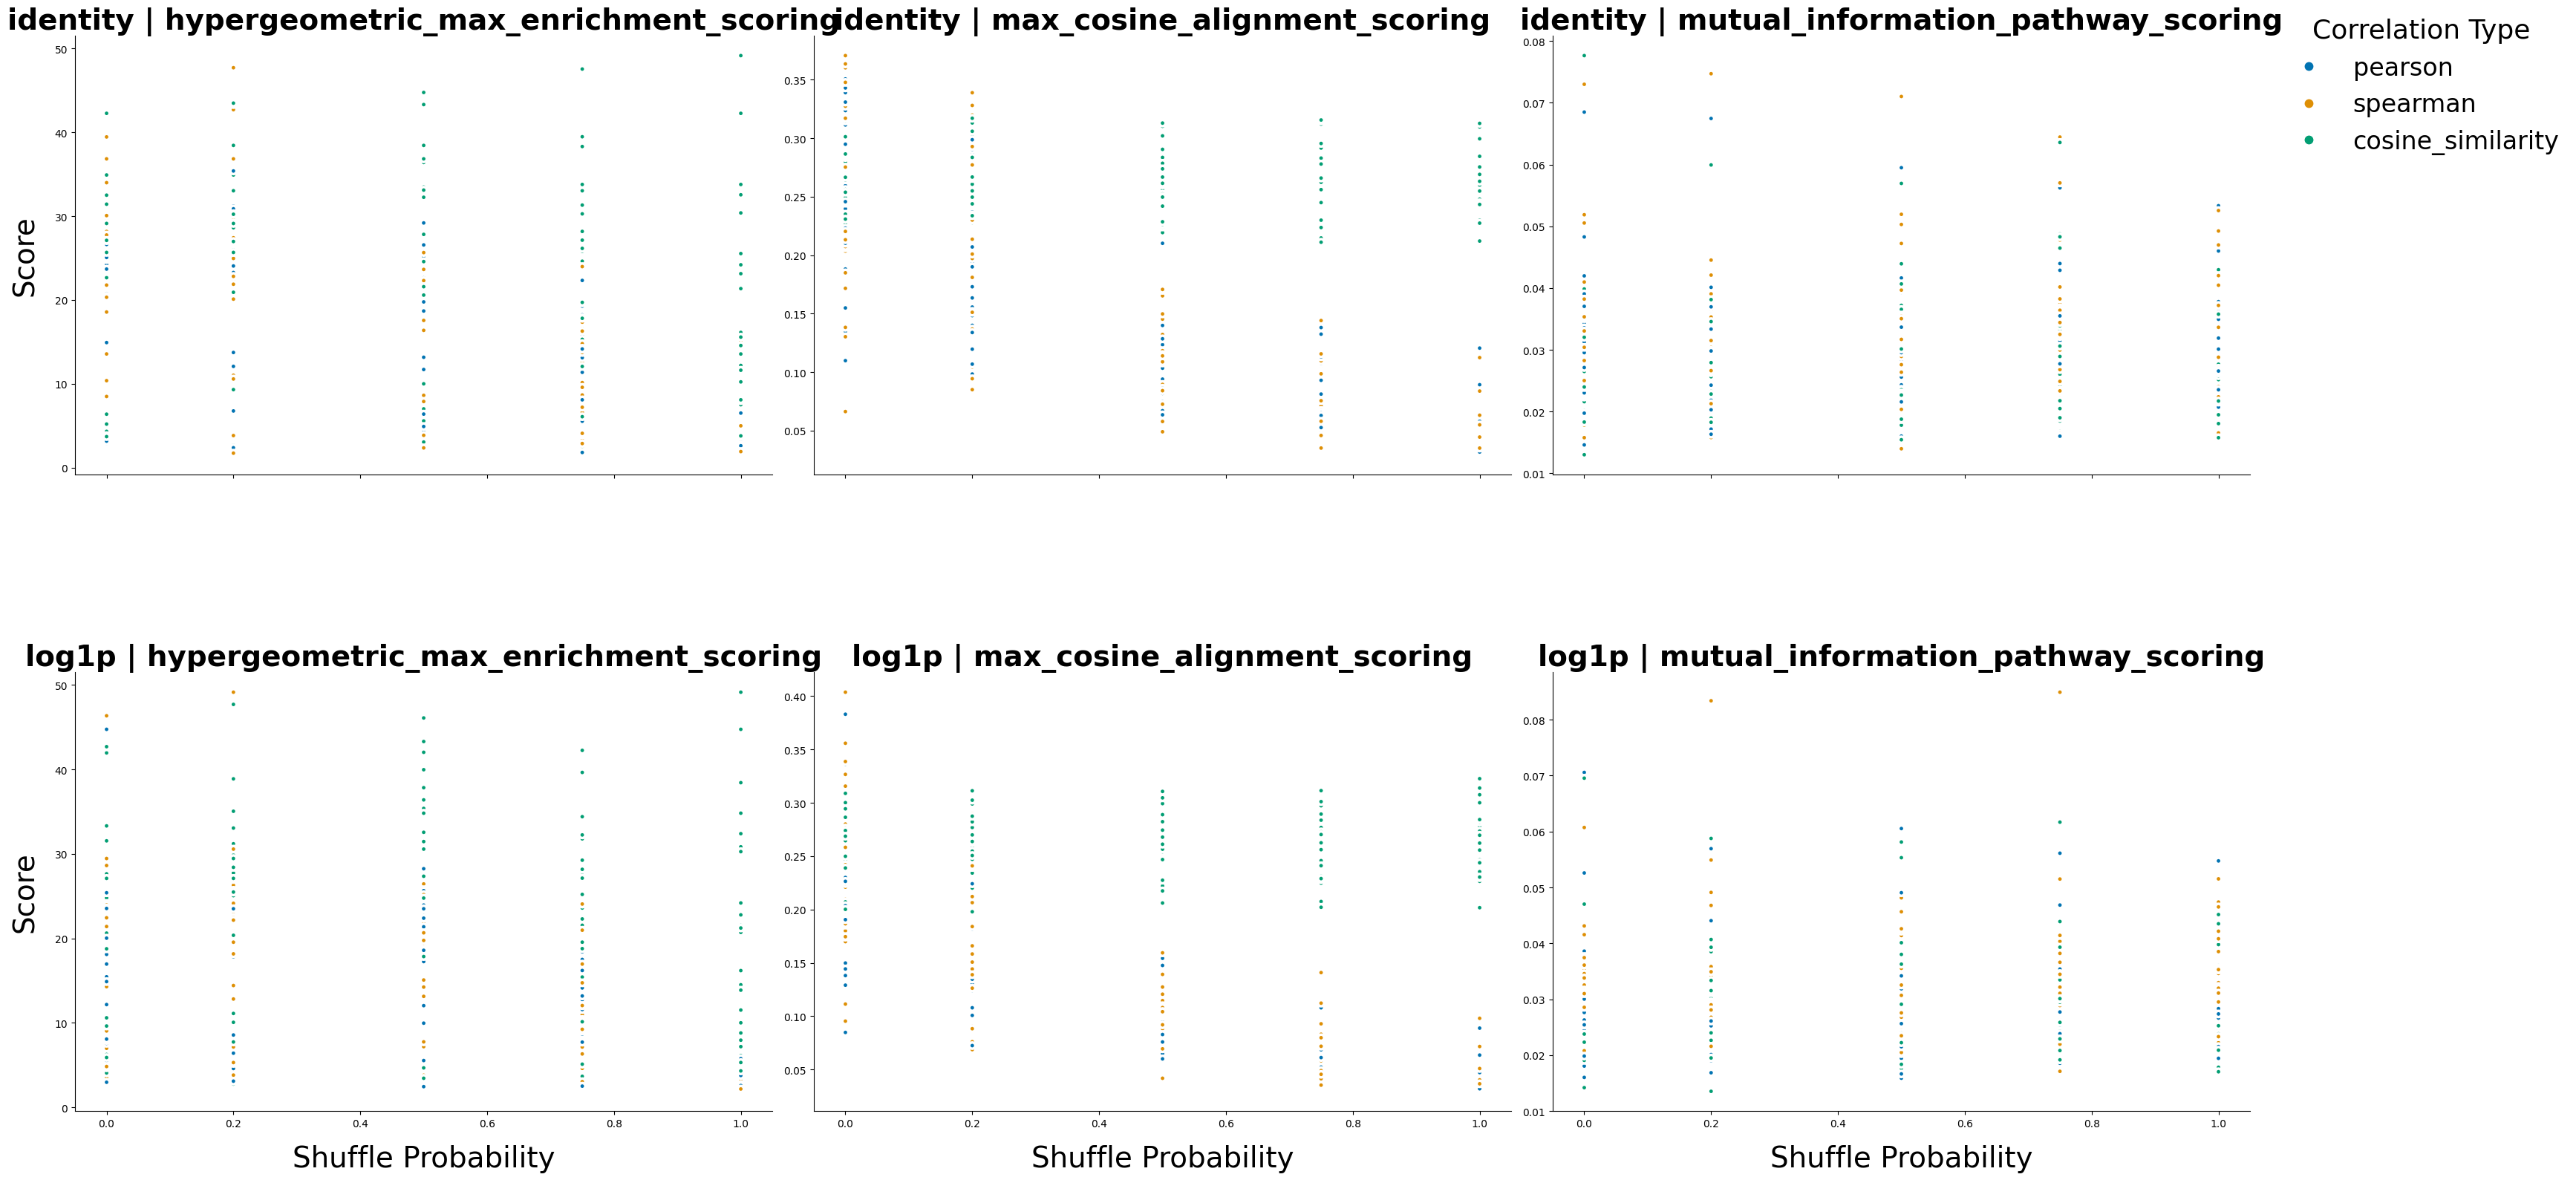

In [10]:
# 2. Generate the plot with a colorblind-friendly palette
g = sns.relplot(
    data=df,
    x="shuffle_probability",
    y="score",
    hue="correlation_name",
    row="preprocessing_name",
    col="scoring_function_name",
    kind="scatter",
    facet_kws={"sharey": False},
    aspect=1.2,
    height=8,  # Slightly scaled down for standard paper margins
    palette="colorblind",  # Ensures accessibility
    linewidth=2.5,  # Makes lines visible at high resolution
)

# 3. Format the Subtitles safely (No \n, just push the layout)
g.set_titles(
    row_template="{row_name}",
    col_template="{col_name}",
    size=28,  # Matches the scale of your massive plot
    weight="bold",  # Makes structural grid labels stand out
)

# 4. Scale up the Axis Labels and Ticks to match your Title scale
g.set_xlabels("Shuffle Probability", fontsize=28, labelpad=15)
g.set_ylabels("Score", fontsize=28, labelpad=15)


# 5. Format the Legend for publication
# Moves it to a clean container, boosts font sizes, and removes the ugly border
sns.move_legend(
    g,
    loc="upper left",
    bbox_to_anchor=(1, 1),
    fontsize=24,
    title="Correlation Type",
    title_fontsize=26,
    frameon=False,
)

# 6. CRITICAL LAYOUT SEQUENCE
# tight_layout must calculate FIRST, subplots_adjust must override LAST
g.figure.tight_layout()
g.figure.subplots_adjust(
    hspace=0.45
)  #
plt.show()